# **HR Analytics using Python**

## IBM Employee Attrition Analysis

### Project Objective

The objective of this project is to analyze employee attrition patterns using the IBM HR Analytics dataset and identify the key factors influencing employee turnover.

The analysis includes data inspection, data cleaning, exploratory data analysis (EDA), statistical analysis, and business recommendations. The findings are intended to support HR decision-making by identifying trends related to employee retention, compensation, job satisfaction, overtime, business travel, and work-life balance.

**Dataset Size:** 1,470 Employees | 35 Features

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Google Colab


# 1. Import Libraries

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

# 2. Load Dataset

In [219]:
path = kagglehub.dataset_download(
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)

print("Dataset downloaded successfully!")
print(path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset downloaded successfully!
/kaggle/input/ibm-hr-analytics-attrition-dataset


In [220]:
print(os.listdir(path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [221]:
csv_path = os.path.join(
    path,
    "WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

df = pd.read_csv(csv_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [222]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [223]:
df.to_csv(
    "/content/drive/MyDrive/HR_Analytics_IBM.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [224]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/HR_Analytics_IBM.csv"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Dataset Description

The IBM HR Analytics dataset contains information for 1,470 employees across 35 attributes, including demographic details, compensation, job role, satisfaction levels, overtime, business travel, and employee attrition. The dataset is commonly used to analyze workforce trends and identify factors influencing employee turnover.

# 3. Initial Data Quality Assessment

In [225]:
# Display first 5 records
print("First 5 Records")
display(df.head())

# Dataset dimensions
print("Dataset Shape:", df.shape)

# Dataset information
print("\nDataset Information")
df.info()

# Missing values
print("\nMissing Values")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

First 5 Records


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Dataset Shape: (1470, 35)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 

## Data Quality Summary

The initial assessment confirmed that the dataset contains **1,470 employee records** with **35 features**.

No missing values or duplicate records were identified, indicating that the dataset is complete and suitable for analysis.

The dataset contains a combination of numerical and categorical variables related to employee demographics, compensation, job characteristics, and performance. Data types were reviewed to ensure compatibility with subsequent analysis and visualization tasks.

Based on the quality assessment, no major preprocessing was required before beginning the exploratory data analysis.


# 4. Data Cleaning

In [226]:
# Check duplicate Employee IDs
print("Duplicate Employee Numbers:", df["EmployeeNumber"].duplicated().sum())

# Check unique values in EmployeeCount
print("\nEmployeeCount")
print(df["EmployeeCount"].value_counts())

# Check unique values in StandardHours
print("\nStandardHours")
print(df["StandardHours"].value_counts())

# Remove constant-value columns that do not contribute to analysis
df = df.drop(
    columns=[
        "EmployeeCount",
        "StandardHours",
        "Over18"
    ]
)

print(df.shape)

Duplicate Employee Numbers: 0

EmployeeCount
EmployeeCount
1    1470
Name: count, dtype: int64

StandardHours
StandardHours
80    1470
Name: count, dtype: int64
(1470, 32)


## Data Cleaning Summary

Although the dataset required minimal preprocessing, several validation steps were performed to ensure data quality before analysis.

Cleaning activities included:

* Verified that Employee Number values were unique.
* Confirmed there were no duplicate employee records.
* Verified that no missing values were present.
* Removed constant-value columns (`EmployeeCount`, `StandardHours`, and `Over18`) because they did not provide analytical value.
* Created an `Attrition_Flag` variable during analysis to simplify attrition rate calculations.
* Validated the dataset before proceeding with exploratory data analysis.


# Project Workflow

1. Data Collection
2. Data Inspection
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Statistical Analysis
6. Business Insights
7. Recommendations

# 5. Exploratory Data Analysis (EDA)

## 5.1 Workforce Demographics




### 5.1.1 Employee Distribution by Department

In [227]:
# Count employees in each department
department_count = (
    df["Department"]
    .value_counts()
)

print("Employee Count by Department")
print(department_count)

# Calculate percentage distribution
department_percentage = (
    df["Department"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPercentage Distribution")
print(department_percentage)

Employee Count by Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Percentage Distribution
Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64


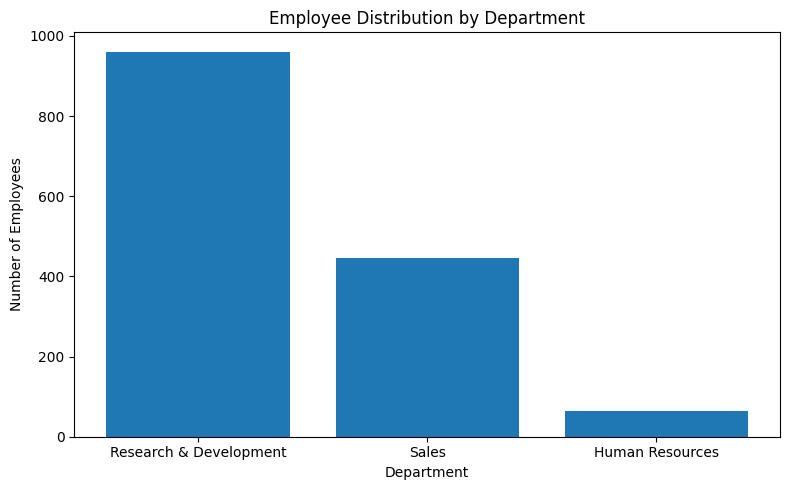

In [228]:
plt.figure(figsize=(8,5))

plt.bar(
    department_count.index,
    department_count.values
)

plt.title("Employee Distribution by Department")

plt.xlabel("Department")

plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig("department_distribution.png", dpi=300)

plt.show()

### Business Insight

The organization's workforce is heavily concentrated in Research & Development (65.37%), indicating a strong focus on research, innovation, and product development activities. The Sales department (30.34%) represents a significant portion of the workforce, reflecting the importance of revenue generation and customer acquisition. The Human Resources department (4.29%) has the smallest workforce, which is typical for support functions that require fewer employees compared to operational departments.

---
### Recommendation

Management should periodically review workforce allocation to ensure that support functions such as Human Resources have sufficient capacity to support recruitment, onboarding, employee engagement, and organizational growth.

### 5.1.2 Gender Distribution

In [229]:
# Employee distribution by gender
gender_count = (
    df["Gender"]
    .value_counts()
)

print("Employee Count by Gender")
print(gender_count)

# Percentage distribution
gender_percentage = (
    df["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPercentage Distribution")
print(gender_percentage)

Employee Count by Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Percentage Distribution
Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64


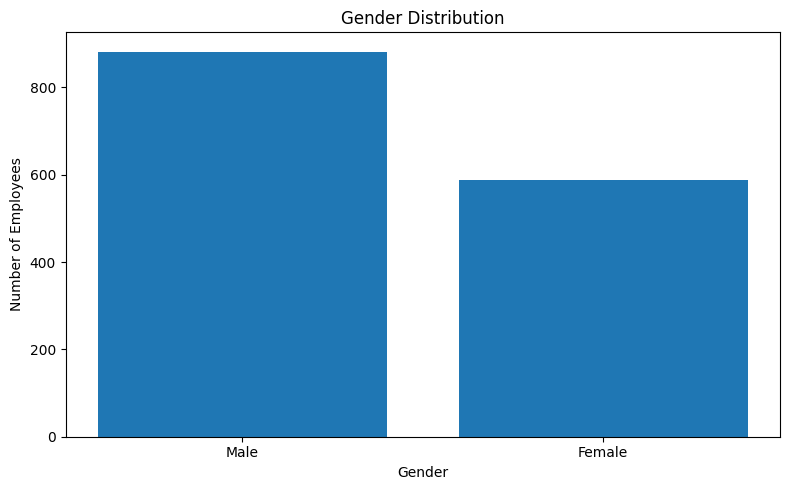

In [230]:
plt.figure(figsize=(8,5))

plt.bar(
    gender_count.index,
    gender_count.values
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig("gender_distribution.png", dpi=300)

plt.show()

### Business Insight

The workforce consists of 60% male and 40% female employees, indicating a moderately diverse employee base. Monitoring gender distribution helps HR evaluate diversity initiatives and identify opportunities to improve representation across departments and job roles.

----

### Recommendation

Management should continue promoting equal hiring, promotion, and career development opportunities while tracking diversity metrics across departments and leadership positions.

### 5.1.3 Age Distribution

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64


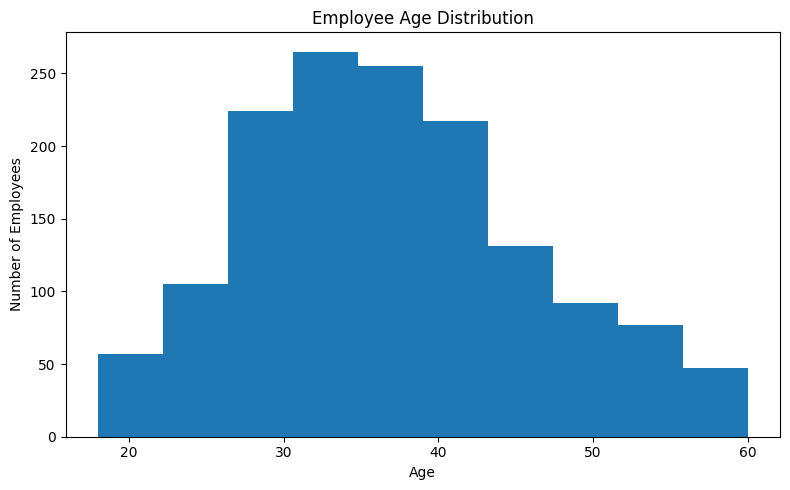

In [231]:
print(df["Age"].describe())

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.title("Employee Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Employees")

plt.tight_layout()

plt.savefig("age_distribution.png", dpi=300)

plt.show()

### Business Insight

The age distribution provides an overview of the organization's workforce demographics. It helps identify whether the company employs predominantly early-career, mid-career, or experienced professionals.

---

### Recommendation

HR should maintain a balanced workforce across different age groups to support knowledge sharing, succession planning, and long-term organizational growth.

## 5.2 Employee Attrition Analysis

### 5.2.1 Overall Employee Attrition Rate

In [232]:
# Create numeric attrition flag
df["Attrition_Flag"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

overall_attrition = (
    df["Attrition_Flag"]
    .mean()
    .round(2)*100
)

print("Overall Attrition Rate:", overall_attrition,"%")

Overall Attrition Rate: 16.0 %


### Business Insight

The organization's overall attrition rate is 16%, meaning approximately 16 out of every 100 employees left during the analyzed period. Attrition is a critical HR metric because higher turnover increases recruitment costs, training expenses, and productivity loss.

----

### Recommendation

HR should continuously monitor attrition trends and identify the primary drivers of employee turnover through department-level, role-level, and employee satisfaction analyses.

### 5.2.2 Department-wise Attrition Analysis

In [233]:
department_attrition = (
    df.groupby("Department")["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(department_attrition)

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition_Flag, dtype: float64


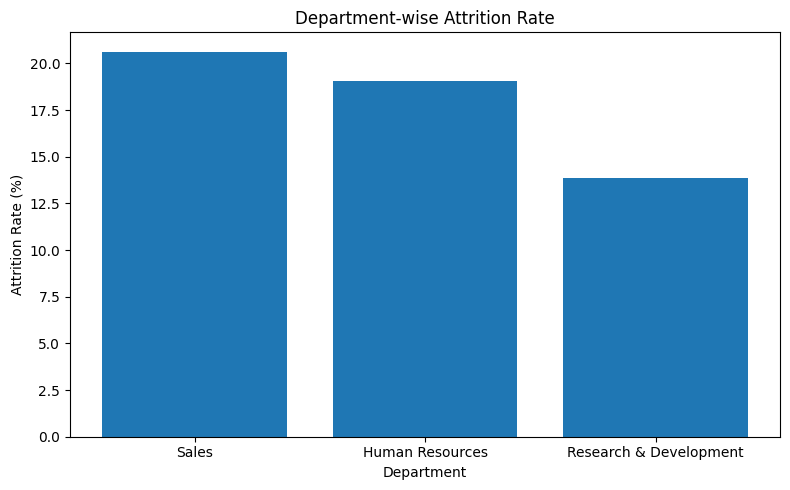

In [234]:
plt.figure(figsize=(8,5))

plt.bar(
    department_attrition.index,
    department_attrition.values
)

plt.title("Department-wise Attrition Rate")

plt.xlabel("Department")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("department_attrition.png", dpi=300)

plt.show()

### Business Insight

The Sales department has the highest attrition rate (20.63%), followed by Human Resources (19.05%). In comparison, Research & Development (13.84%) has a lower attrition rate despite having the largest workforce. This suggests that employee retention challenges may be more pronounced in Sales and HR than in Research & Development.

----
### Recommendation

HR should prioritize retention initiatives in the Sales and Human Resources departments and investigate factors such as workload, compensation, leadership, career growth opportunities, and employee engagement.

### 5.2.3 Job Role-wise Attrition

In [235]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(jobrole_attrition)

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition_Flag, dtype: float64


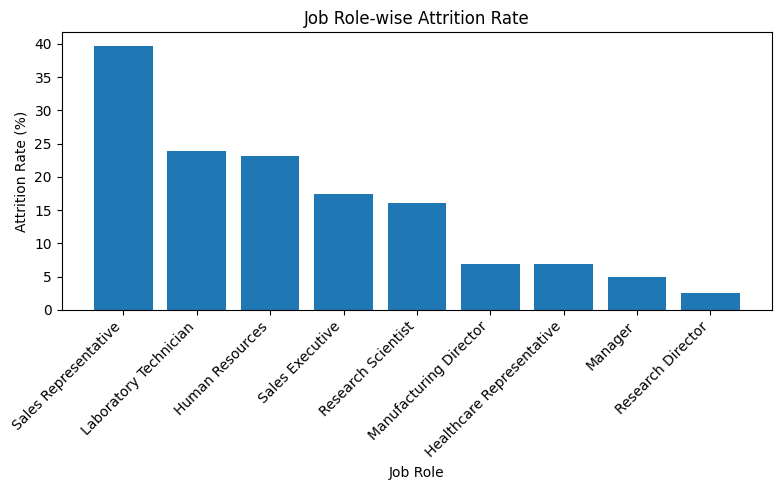

In [236]:
plt.figure(figsize=(8,5))

plt.bar(
    jobrole_attrition.index,
    jobrole_attrition.values
)

plt.title("Job Role-wise Attrition Rate")

plt.xlabel("Job Role")

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("job_role_attrition.png", dpi=300)

plt.show()

### Business Insight

Attrition varies significantly across job roles. Sales Representatives have the highest attrition rate (39.76%), followed by Laboratory Technicians (23.94%) and Human Resources (23.08%). In contrast, Research Directors (2.50%) and Managers (4.90%) have the lowest attrition rates. This suggests that entry-level or operational roles experience higher employee turnover than senior leadership positions.

---

### Recommendation

HR should prioritize retention strategies for high-turnover roles by reviewing compensation, career progression, workload, onboarding, and employee engagement initiatives.

## 5.3 Employee Engagement Analysis

### 5.3.1 Job Satisfaction vs Attrition

In [237]:
job_satisfaction_attrition = (
    df.groupby("JobSatisfaction")["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(job_satisfaction_attrition)

JobSatisfaction
1    22.84
3    16.52
2    16.43
4    11.33
Name: Attrition_Flag, dtype: float64


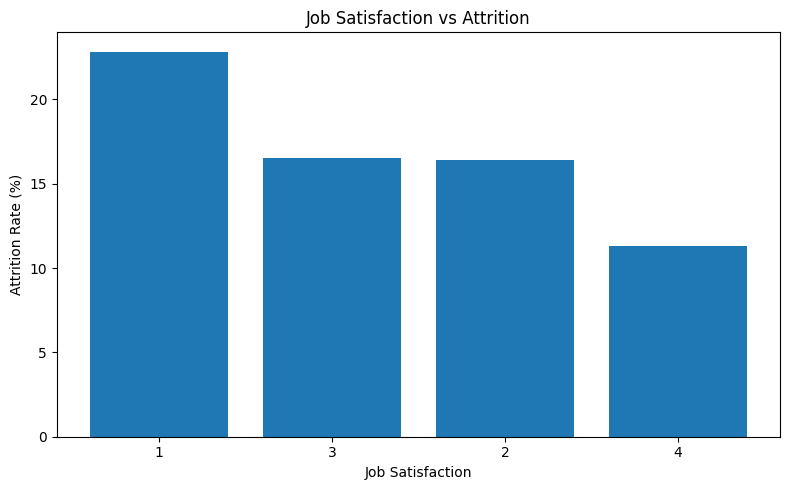

In [238]:
plt.figure(figsize=(8,5))

plt.bar(
    job_satisfaction_attrition.index.astype(str),
    job_satisfaction_attrition.values
)

plt.title("Job Satisfaction vs Attrition")

plt.xlabel("Job Satisfaction")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("job_satisfaction_attrition.png", dpi=300)

plt.show()

### Business Insight

Employees with the lowest job satisfaction score (1) have the highest attrition rate at 22.84%, while employees with the highest satisfaction score (4) have the lowest attrition rate at 11.33%. This demonstrates a clear relationship between job satisfaction and employee retention.

---

### Recommendation

HR should regularly measure employee satisfaction and implement initiatives focused on recognition, career development, workload management, and employee engagement to improve retention.

### 5.3.2 Work-Life Balance vs Attrition

In [239]:
worklife_attrition = (
    df.groupby("WorkLifeBalance")["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(worklife_attrition)

WorkLifeBalance
1    31.25
4    17.65
2    16.86
3    14.22
Name: Attrition_Flag, dtype: float64


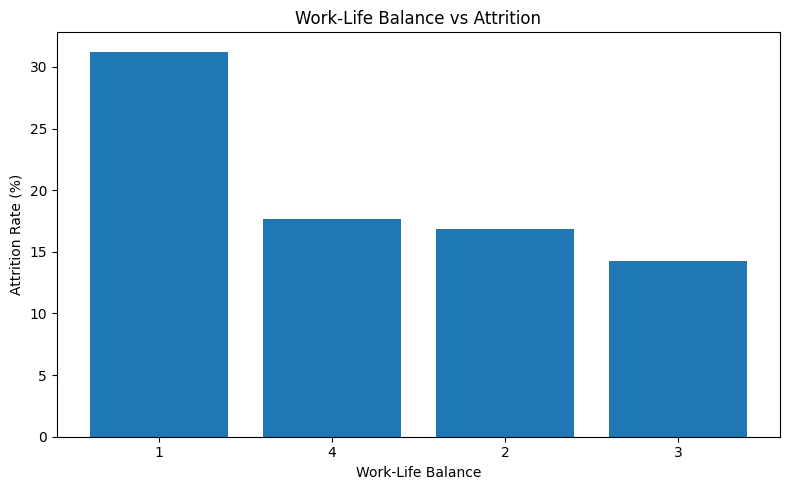

In [240]:
plt.figure(figsize=(8,5))

plt.bar(
    worklife_attrition.index.astype(str),
    worklife_attrition.values
)

plt.title("Work-Life Balance vs Attrition")

plt.xlabel("Work-Life Balance")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("worklife_balance_attrition.png", dpi=300)

plt.show()

### Business Insight

Employees with the lowest Work-Life Balance rating (1) have the highest attrition rate (31.25%), while employees reporting better work-life balance generally experience lower attrition. This indicates that maintaining a healthy balance between professional and personal life plays an important role in employee retention.

### Recommendation

Management should promote flexible work arrangements, balanced workloads, employee wellness programs, and supportive management practices to improve work-life balance and reduce employee turnover.


### 5.3.3 Overtime vs Attrition

In [241]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(overtime_attrition)

OverTime
Yes    30.53
No     10.44
Name: Attrition_Flag, dtype: float64


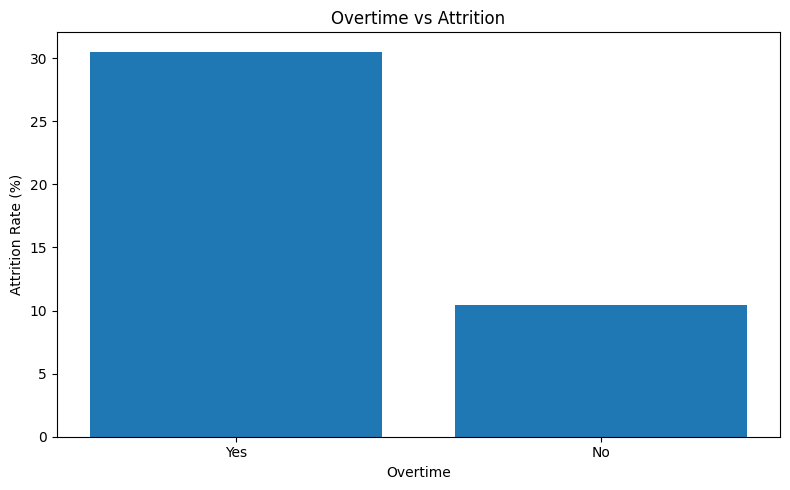

In [242]:
plt.figure(figsize=(8,5))

plt.bar(
    overtime_attrition.index,
    overtime_attrition.values
)

plt.title("Overtime vs Attrition")

plt.xlabel("Overtime")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("overtime_attrition.png", dpi=300)

plt.show()

### Business Insight

Employees who work overtime have an attrition rate of 30.53%, compared with 10.44% for employees who do not work overtime. This indicates a strong association between overtime and employee turnover, suggesting that workload and work-life balance may significantly influence retention.

---
### Recommendation

Management should review overtime policies, staffing levels, and workload distribution to reduce employee burnout and improve retention.

## 5.4 Compensation Analysis

### 5.4.1 Monthly Income by Department

In [243]:
# Average monthly income by department
department_salary = (
    df.groupby("Department")["MonthlyIncome"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print("Average Monthly Income by Department")
print(department_salary)

Average Monthly Income by Department
Department
Sales                     6959.17
Human Resources           6654.51
Research & Development    6281.25
Name: MonthlyIncome, dtype: float64


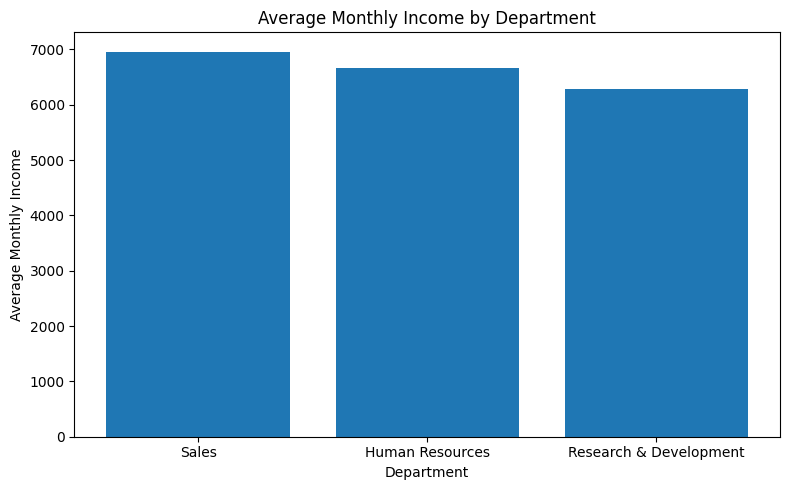

In [244]:
plt.figure(figsize=(8,5))

plt.bar(
    department_salary.index,
    department_salary.values
)

plt.title("Average Monthly Income by Department")

plt.xlabel("Department")

plt.ylabel("Average Monthly Income")

plt.tight_layout()

plt.savefig("monthly_income_department.png", dpi=300)

plt.show()

### Business Insight

The Sales department has the highest average monthly income (6,959.17), followed by Human Resources (6,654.51) and Research & Development (6,281.25). The higher average income in Sales may be influenced by incentive-based compensation, commissions, or senior sales positions. Although Research & Development has the largest workforce, its average monthly income is comparatively lower.

---

### Recommendation

Management should periodically review compensation structures across departments to ensure salary decisions remain competitive, equitable, and aligned with employee responsibilities and market standards.

### 5.4.2 Total Working Years vs Monthly Income

In [245]:
correlation = (
    df["TotalWorkingYears"]
    .corr(df["MonthlyIncome"])
)

print("Correlation:", round(correlation, 2))

Correlation: 0.77


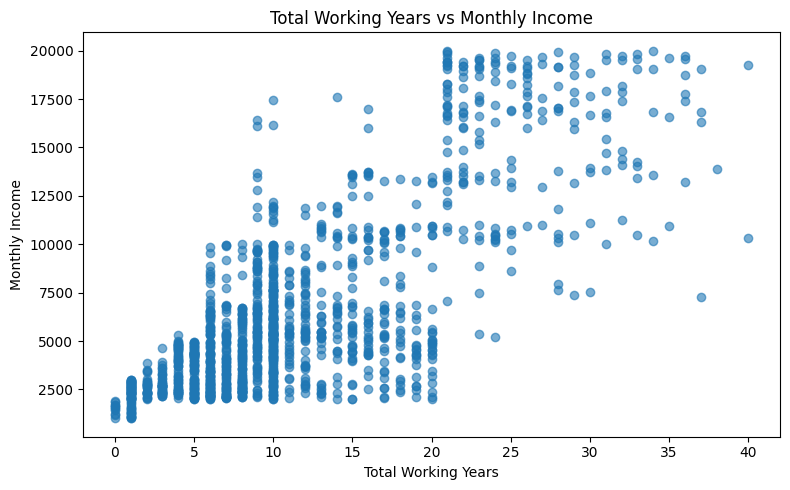

In [246]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["TotalWorkingYears"],
    df["MonthlyIncome"],
    alpha=0.6
)

plt.title("Total Working Years vs Monthly Income")

plt.xlabel("Total Working Years")

plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("experience_income_scatter.png", dpi=300)

plt.show()

### Business Insight

The correlation coefficient between Total Working Years and Monthly Income is 0.77, indicating a strong positive relationship. Employees with more total work experience generally earn higher salaries. The scatter plot also shows an upward trend, supporting the positive association between experience and compensation.

---

### Recommendation

Management should continue aligning compensation with employee experience while also ensuring that high-performing employees receive competitive salary growth regardless of tenure.

## 5.5 Business Travel Analysis

### 5.5.1 Business Travel vs Attrition

In [247]:
travel_attrition = (
    df.groupby("BusinessTravel")["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(travel_attrition)

BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition_Flag, dtype: float64


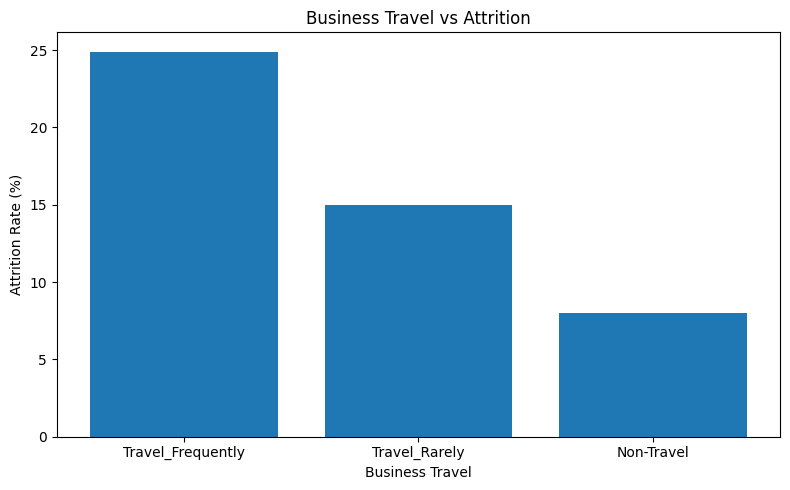

In [248]:
plt.figure(figsize=(8,5))

plt.bar(
    travel_attrition.index,
    travel_attrition.values
)

plt.title("Business Travel vs Attrition")

plt.xlabel("Business Travel")

plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("business_travel_attrition.png", dpi=300)

plt.show()

### Business Insight

Employees who travel frequently have the highest attrition rate (24.91%), compared with employees who travel rarely (14.96%) and non-travel employees (8.00%). This indicates that frequent business travel may negatively impact employee retention, possibly due to work-life balance challenges and increased job-related stress.

----

### Recommendation

Management should evaluate travel policies and consider flexible work arrangements, travel rotation, or additional employee support to reduce the impact of frequent travel.

# **Executive Summary**

This HR Analytics project analyzes employee workforce data from IBM's HR Analytics dataset using Python and Pandas. The objective is to identify key factors affecting employee attrition and provide business recommendations to improve employee retention.

The project includes data cleaning, exploratory data analysis (EDA), statistical analysis, and data visualization. Various HR metrics such as department distribution, gender diversity, attrition, overtime, work-life balance, job satisfaction, business travel, compensation, and employee experience were analyzed to support data-driven decision making.

The analysis revealed that employee attrition is strongly associated with overtime, job satisfaction, work-life balance, frequent business travel, and specific job roles. These insights can help HR departments develop targeted retention strategies and optimize workforce planning.

| KPI                           |               Result |
| ----------------------------- | -------------------: |
| Employees                     |                1,470 |
| Departments                   |                    3 |
| Overall Attrition             |                  16% |
| Highest Attrition Department  |                Sales |
| Highest Risk Job Role         | Sales Representative |
| Overtime Attrition            |               30.53% |
| Experience–Income Correlation |                 0.77 |


# **Key Business Findings**

1. Research & Development represents over 65% of the workforce, indicating that the company primarily focuses on research and innovation.

2. The overall employee attrition rate is approximately 16%, meaning nearly one out of every six employees leaves the organization.

3. Sales employees experience the highest department-level attrition rate, suggesting a greater retention challenge compared to other departments.

4. Employees working overtime have nearly three times higher attrition than employees who do not work overtime.

5. Employees with the lowest job satisfaction show the highest attrition rate, demonstrating a strong relationship between employee satisfaction and retention.

6. Frequent business travel is associated with increased employee attrition, indicating that extensive travel may negatively affect work-life balance.

7. Total working years and monthly income have a strong positive correlation (0.77), suggesting that employee experience generally leads to higher compensation.

# **Business Recommendations**

• Reduce excessive overtime by improving workforce planning and workload distribution.

• Increase employee engagement through recognition programs, career development opportunities, and regular feedback sessions.

• Conduct employee satisfaction surveys to identify workplace issues before employees resign.

• Review compensation structures periodically to ensure salaries remain competitive with industry standards.

• Provide flexible work arrangements and wellness programs to improve work-life balance.

• Monitor departments and job roles with high attrition and implement targeted retention strategies.

• Evaluate business travel policies and provide additional support for employees who travel frequently.

# **Conclusion**

This project demonstrates how Python can be used to solve real-world HR business problems through data analysis.

Using Pandas and Matplotlib, employee data was cleaned, explored, analyzed, and visualized to identify factors influencing employee attrition.

The findings indicate that overtime, job satisfaction, work-life balance, business travel, and employee roles significantly impact employee retention.

These insights enable HR managers to make data-driven decisions that improve employee engagement, reduce turnover, and support long-term organizational growth.

# **Skills Demonstrated**

• Python

• Pandas

• NumPy

• Matplotlib

• Data Cleaning

• Exploratory Data Analysis (EDA)

• Data Visualization

• GroupBy & Aggregation

• Correlation Analysis

• Business Problem Solving

• HR Analytics

• Statistical Analysis

• Business Insights & Recommendations